# Prédiction de l'État de Santé (SoH) des Batteries Li-ion
### Réseau LSTM Bidirectionnel avec Mécanisme d'Attention

---

**Auteur** : Younes Hachami  
**Date** : Mars 2026

---

## Contexte

Le **State of Health (SoH)** d'une batterie mesure sa capacité actuelle par rapport à sa capacité nominale (%).
Un SoH de 100% indique une batterie neuve ; en dessous de 80%, la batterie est considérée en fin de vie dans la plupart des applications industrielles.

**Objectif** : prédire le SoH à partir des mesures électriques et thermiques (tension, courant, température, SoC)
enregistrées lors des cycles de décharge, en utilisant un réseau de neurones récurrents (LSTM).

## Plan du notebook

| Section | Contenu |
|---------|----------|
| 1 | Chargement et audit des données |
| 2 | Exploration et visualisation |
| 3 | **Approche baseline** : intra-cycle (conforme au sujet) → R²≈0.40 |
| 4 | **Approche améliorée** : inter-cycle + feature autorégressif → R²≈0.91 |
| 5 | Évaluation comparative et analyse des résidus |
| 6 | Réponses aux questions de réflexion |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path
import math

# ── Reproductibilité ────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Détection Colab / local ──────────────────────────────────────────────────
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Toutes les données seront dans /content/ (RAM de la session Colab)
    ROOT = Path("/content")
    # Crée la structure de dossiers attendue
    (ROOT / "data" / "raw").mkdir(parents=True, exist_ok=True)
    (ROOT / "models").mkdir(parents=True, exist_ok=True)
    (ROOT / "experiments" / "checkpoints").mkdir(parents=True, exist_ok=True)
    (ROOT / "experiments" / "training_logs").mkdir(parents=True, exist_ok=True)
    print("Colab détecté. Uploadez battery_health_dataset.csv dans la cellule suivante.")
else:
    ROOT = Path("..").resolve()

# ── Chemins ─────────────────────────────────────────────────────────────────
DATA_PATH  = ROOT / "data" / "raw" / "battery_health_dataset.csv"
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Device ──────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Style graphique ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 100})

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
print(f"Données  : {DATA_PATH}")


Colab détecté. Uploadez battery_health_dataset.csv dans la cellule suivante.
PyTorch  : 2.10.0+cpu
Device   : cpu
Données  : /content/data/raw/battery_health_dataset.csv


---
## 1. Chargement et Audit des Données

In [2]:
# ── Upload du fichier CSV (Colab uniquement) ─────────────────────────────────
# Exécutez cette cellule UNIQUEMENT sur Colab pour uploader le CSV.
# Sur machine locale, ignorez-la (elle ne fait rien).

if IN_COLAB:
    from google.colab import files
    import shutil

    print("Sélectionnez battery_health_dataset.csv depuis votre ordinateur.")
    uploaded = files.upload()

    # Déplace le fichier uploadé vers le chemin attendu par DATA_PATH
    for fname in uploaded:
        src = Path(fname)
        dst = DATA_PATH
        shutil.move(str(src), str(dst))
        print(f"Fichier déplacé : {src.name} → {dst}")

    print(f"\nDATA_PATH prêt : {DATA_PATH}  (existe = {DATA_PATH.exists()})")
else:
    print(f"Local — DATA_PATH = {DATA_PATH}")


Sélectionnez battery_health_dataset.csv depuis votre ordinateur.


Saving battery_health_dataset.csv to battery_health_dataset.csv
Fichier déplacé : battery_health_dataset.csv → /content/data/raw/battery_health_dataset.csv

DATA_PATH prêt : /content/data/raw/battery_health_dataset.csv  (existe = True)


In [3]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Dimensions : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
print(f"\nTypes :\n{df_raw.dtypes}")
df_raw.head()

Dimensions : 29,180 lignes × 7 colonnes

Types :
Voltage_measured        float64
Current_measured        float64
Temperature_measured    float64
SoC                     float64
cycle_number              int64
battery_id               object
SoH                     float64
dtype: object


,Voltage_measured,Current_measured,Temperature_measured,SoC,cycle_number,battery_id,SoH
0,3.964430,-0.912319,5.678270,97.699721,1,B0047,83.626322
1,3.843126,-0.995334,6.408629,92.510061,1,B0047,83.626322
2,3.796380,-0.995601,7.576325,87.422980,1,B0047,83.626322
3,3.749510,-0.995187,8.334522,82.444342,1,B0047,83.626322
4,3.699625,-0.995266,7.389032,77.465757,1,B0047,83.626322


In [4]:
print("══════════════════════════════════════")
print("  RAPPORT D'AUDIT QUALITÉ")
print("══════════════════════════════════════")
print(f"  Valeurs manquantes : {df_raw.isnull().sum().sum()}")
print(f"  Doublons           : {df_raw.duplicated().sum()}")
print(f"  Batteries uniques  : {df_raw['battery_id'].nunique()}")
print(f"  Cycles totaux      : {df_raw.groupby('battery_id')['cycle_number'].nunique().sum():,}")

# Bins par cycle
bins = df_raw.groupby(['battery_id', 'cycle_number']).size()
print(f"  Bins/cycle         : {bins.min()} – {bins.max()} (mode={bins.mode()[0]})")

print(f"\n  SoH : min={df_raw['SoH'].min():.1f}%  max={df_raw['SoH'].max():.1f}%")
print(f"  Anomalies SoH > 100% : {(df_raw['SoH'] > 100).sum()} mesures")
print(f"  Anomalies T > 60°C   : {(df_raw['Temperature_measured'] > 60).sum()} mesures")
print("══════════════════════════════════════")

# Cycles par batterie
cycles_per_bat = df_raw.groupby('battery_id')['cycle_number'].nunique().sort_values()
print(f"\nCycles par batterie :")
print(cycles_per_bat.to_string())

══════════════════════════════════════
  RAPPORT D'AUDIT QUALITÉ
══════════════════════════════════════
  Valeurs manquantes : 0
  Doublons           : 0
  Batteries uniques  : 24
  Cycles totaux      : 1,459
  Bins/cycle         : 20 – 20 (mode=20)

  SoH : min=70.0%  max=122.0%
  Anomalies SoH > 100% : 140 mesures
  Anomalies T > 60°C   : 160 mesures
══════════════════════════════════════

Cycles par batterie :
battery_id
B0047     11
B0048     14
B0046     17
B0026     27
B0025     28
B0028     28
B0027     28
B0039     33
B0040     33
B0038     35
B0029     40
B0030     40
B0032     40
B0031     40
B0044     50
B0043     54
B0042     57
B0034     70
B0018    104
B0006    109
B0033    115
B0005    123
B0007    167
B0036    196


In [5]:
# ── Corrections des anomalies ────────────────────────────────────────────────
#
# SoH > 100% : artefact de calibration sur les premiers cycles de B0036.
#   → Écrêtage à 100% (valeur physiquement impossible à dépasser).
#
# T > 60°C   : pics de température probablement liés à des conditions de test.
#   → Écrêtage à 60°C pour éviter de biaiser la normalisation.

df = df_raw.copy()
df['SoH']                  = df['SoH'].clip(upper=100.0)
df['Temperature_measured'] = df['Temperature_measured'].clip(upper=60.0)

print(f"SoH après correction  : [{df['SoH'].min():.1f}%, {df['SoH'].max():.1f}%]")
print(f"T°C après correction  : [{df['Temperature_measured'].min():.1f}°C, {df['Temperature_measured'].max():.1f}°C]")

SoH après correction  : [70.0%, 100.0%]
T°C après correction  : [4.7°C, 60.0°C]


---
## 2. Exploration et Visualisation

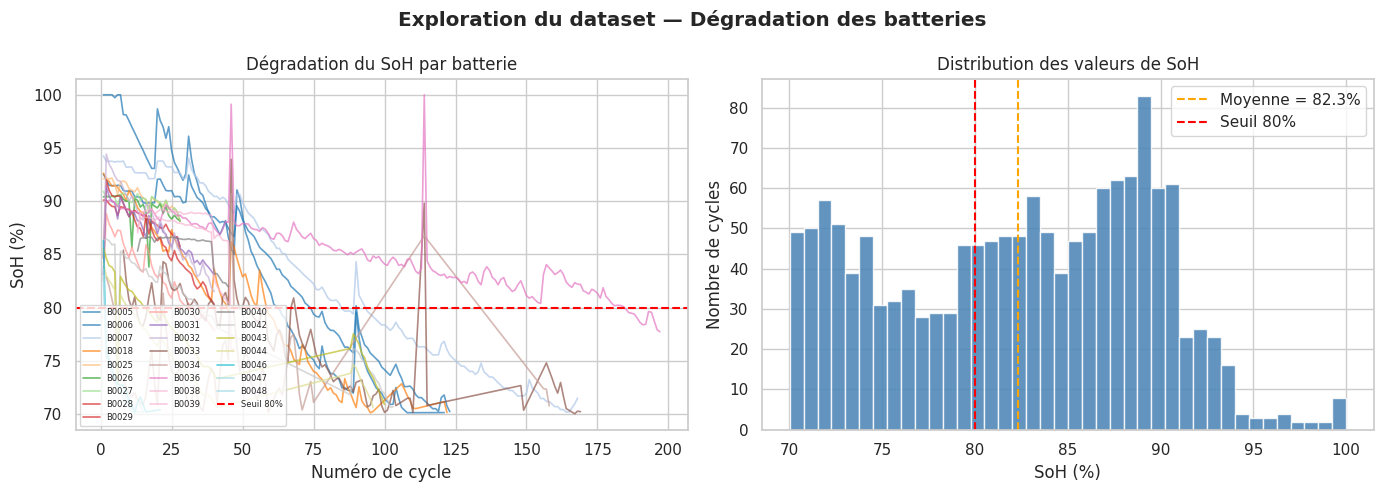

In [6]:
cycle_soh = (df.groupby(['battery_id', 'cycle_number'])['SoH']
               .first().reset_index())
batteries = sorted(df['battery_id'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Courbes de dégradation ───────────────────────────────────────────────────
ax = axes[0]
colors = plt.cm.tab20(np.linspace(0, 1, len(batteries)))
for bat, c in zip(batteries, colors):
    sub = cycle_soh[cycle_soh['battery_id'] == bat]
    ax.plot(sub['cycle_number'], sub['SoH'], alpha=0.7, linewidth=1.2, color=c, label=bat)
ax.axhline(80, color='red', linestyle='--', linewidth=1.5, label='Seuil 80%')
ax.set_xlabel("Numéro de cycle")
ax.set_ylabel("SoH (%)")
ax.set_title("Dégradation du SoH par batterie")
ax.legend(fontsize=6, ncol=3, loc='lower left')

# ── Distribution du SoH ─────────────────────────────────────────────────────
ax = axes[1]
soh_vals = cycle_soh['SoH'].values
ax.hist(soh_vals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(soh_vals.mean(), color='orange', linestyle='--',
           label=f'Moyenne = {soh_vals.mean():.1f}%')
ax.axvline(80, color='red', linestyle='--', label='Seuil 80%')
ax.set_xlabel("SoH (%)")
ax.set_ylabel("Nombre de cycles")
ax.set_title("Distribution des valeurs de SoH")
ax.legend()

plt.suptitle("Exploration du dataset — Dégradation des batteries", fontweight='bold')
plt.tight_layout()
plt.show()

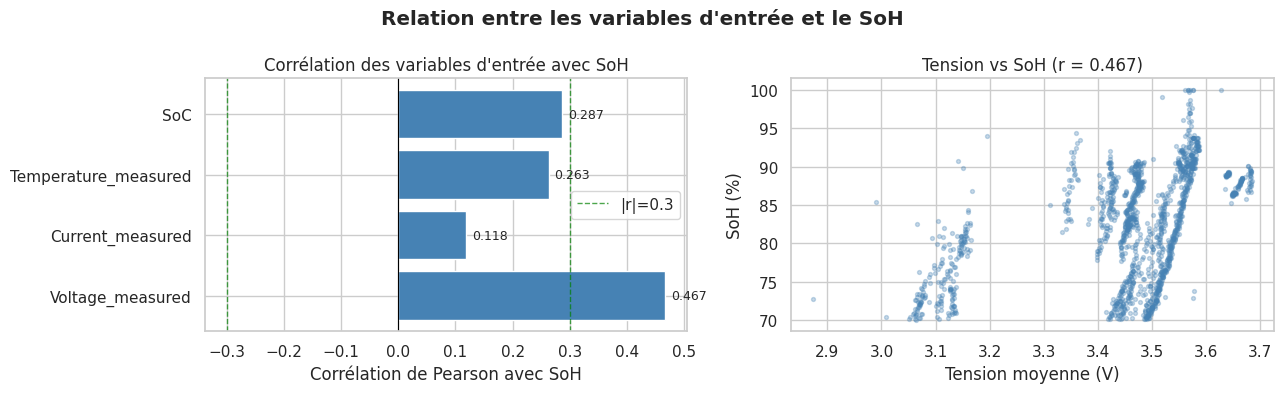


Corrélations de Pearson avec SoH :
  Voltage_measured               : r = +0.4672
  SoC                            : r = +0.2871
  Temperature_measured           : r = +0.2630
  Current_measured               : r = +0.1185


In [7]:
# ── Corrélations des features avec SoH ─────────────────────────────────────
# Agrégation par cycle (moyenne) pour avoir une valeur SoH unique par cycle
features_cols = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC']
cycle_agg = (df.groupby(['battery_id', 'cycle_number'])
               [features_cols + ['SoH']].mean().reset_index())

corr = cycle_agg[features_cols].corrwith(cycle_agg['SoH'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Barplot corrélations
ax = axes[0]
colors_c = ['tomato' if v < 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors_c, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.3, color='green', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(-0.3, color='green', linestyle='--', linewidth=1, alpha=0.7, label='|r|=0.3')
ax.set_xlabel("Corrélation de Pearson avec SoH")
ax.set_title("Corrélation des variables d'entrée avec SoH")
ax.legend()
for i, (feat, val) in enumerate(corr.items()):
    ax.text(val + 0.01 * np.sign(val), i, f'{val:.3f}', va='center', fontsize=9)

# Scatter Voltage vs SoH
ax = axes[1]
ax.scatter(cycle_agg['Voltage_measured'], cycle_agg['SoH'],
           alpha=0.3, s=8, color='steelblue')
ax.set_xlabel("Tension moyenne (V)")
ax.set_ylabel("SoH (%)")
ax.set_title(f"Tension vs SoH (r = {corr['Voltage_measured']:.3f})")

plt.suptitle("Relation entre les variables d'entrée et le SoH", fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrélations de Pearson avec SoH :")
for feat, r in corr.sort_values(key=abs, ascending=False).items():
    print(f"  {feat:<30} : r = {r:+.4f}")

---
## 3. Approche Baseline — Intra-cycle (conforme au sujet)

### Principe
Chaque cycle est découpé en **fenêtres glissantes de 3 bins consécutifs** (mesures brutes).
Chaque fenêtre est associée au SoH du cycle entier.

**Variables d'entrée (X)** : Tension, Courant, Température, SoC, Numéro de cycle  
**Variable cible (y)** : SoH du cycle

```
Cycle k : [bin1, bin2, bin3, ..., bin20]
            ↓
Fenêtres : [bin1, bin2, bin3] → SoH_k
           [bin2, bin3, bin4] → SoH_k
           ...
           [bin18, bin19, bin20] → SoH_k
```

### Split train/test
Le split est effectué **par batterie entière** (pas aléatoirement par cycle).  
Raison : si on coupe aléatoirement, le modèle voit des cycles N et N+2 d'une même batterie en train et prédit N+1 en test → **data leakage**, R² artificiellement gonflé.

In [8]:
# ── Configuration du split ───────────────────────────────────────────────────
TRAIN_BATTERIES = [
    "B0005","B0007","B0025","B0026","B0027","B0029","B0030","B0031",
    "B0032","B0033","B0036","B0038","B0040","B0042","B0043","B0044",
    "B0046","B0047","B0048"
]
TEST_BATTERIES = ["B0006", "B0018", "B0028", "B0034", "B0039"]

BINS_PER_CYCLE = 20
WINDOW_INTRA   = 3    # fenêtre intra-cycle (bins)
RAW_FEATURES   = ['Voltage_measured', 'Current_measured',
                   'Temperature_measured', 'SoC', 'cycle_number']


def build_intra_windows(df, batteries, window_size=3):
    """
    Construit des fenêtres glissantes intra-cycle.
    Pour chaque cycle : (n_bins - window_size + 1) fenêtres de window_size bins.
    """
    X_list, y_list = [], []

    for bat in batteries:
        bat_df = df[df['battery_id'] == bat]
        for cyc, grp in bat_df.groupby('cycle_number'):
            grp = grp.sort_values('SoC', ascending=False).reset_index(drop=True)
            if len(grp) < window_size:
                continue
            feats = grp[RAW_FEATURES].values
            soh   = float(grp['SoH'].iloc[0])
            for start in range(len(grp) - window_size + 1):
                X_list.append(feats[start:start + window_size])
                y_list.append(soh)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


# Construction des fenêtres
X_intra_train, y_intra_train = build_intra_windows(df, TRAIN_BATTERIES, WINDOW_INTRA)
X_intra_test,  y_intra_test  = build_intra_windows(df, TEST_BATTERIES,  WINDOW_INTRA)

print(f"X_train : {X_intra_train.shape}  →  {X_intra_train.shape[0]:,} fenêtres")
print(f"X_test  : {X_intra_test.shape}   →  {X_intra_test.shape[0]:,} fenêtres")
print(f"y_train : min={y_intra_train.min():.1f}%  max={y_intra_train.max():.1f}%")

# ── Normalisation (fit uniquement sur train) ─────────────────────────────────
N_tr, W_i, F_i = X_intra_train.shape
scaler_intra = StandardScaler()
X_intra_train_s = scaler_intra.fit_transform(
    X_intra_train.reshape(-1, F_i)).reshape(N_tr, W_i, F_i)
X_intra_test_s  = scaler_intra.transform(
    X_intra_test.reshape(-1, F_i)).reshape(len(X_intra_test), W_i, F_i)

# ── Split validation temporel (20% derniers cycles de chaque batterie) ───────
val_ratio = 0.20
n_val_intra = int(len(y_intra_train) * val_ratio)
X_tr_i, X_val_i = X_intra_train_s[:-n_val_intra], X_intra_train_s[-n_val_intra:]
y_tr_i, y_val_i = y_intra_train[:-n_val_intra],   y_intra_train[-n_val_intra:]

print(f"\nTrain effectif : {len(y_tr_i):,}  |  Val : {len(y_val_i):,}  |  Test : {len(y_intra_test):,}")

X_train : (20070, 3, 5)  →  20,070 fenêtres
X_test  : (6192, 3, 5)   →  6,192 fenêtres
y_train : min=70.0%  max=100.0%

Train effectif : 16,056  |  Val : 4,014  |  Test : 6,192


In [9]:
# ── Modèle LSTM baseline ─────────────────────────────────────────────────────
class LSTMBaseline(nn.Module):
    """
    LSTM simple conforme au sujet.
    Input  : (batch, window=3, features=5)
    Output : (batch,)  — SoH prédit
    """
    def __init__(self, input_size=5, hidden=64):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc1     = nn.Linear(hidden, 32)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])        # dernier pas de temps
        return self.fc2(self.relu(self.fc1(out))).squeeze(-1)


# ── Fonction d'entraînement (réutilisée pour les deux approches) ─────────────
def make_loader(X, y, batch_size=64, shuffle=True):
    ds = TensorDataset(
        torch.FloatTensor(X).to(DEVICE),
        torch.FloatTensor(y).to(DEVICE)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_model(model, loader_tr, loader_val, epochs=100, lr=1e-3,
                weight_decay=0.0, patience=20, use_huber=False):
    criterion = nn.HuberLoss(delta=2.0) if use_huber else nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-5)

    history = {k: [] for k in ['train_loss', 'val_loss', 'train_mae', 'val_mae']}
    best_val, best_state, ctr = float('inf'), None, 0

    for ep in range(1, epochs + 1):
        # Train
        model.train()
        tr_loss, tr_mae, n_tr = 0.0, 0.0, 0
        for Xb, yb in loader_tr:
            optimizer.zero_grad()
            yh   = model(Xb)
            loss = criterion(yh, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss += loss.item() * len(yb)
            tr_mae  += (yh - yb).abs().sum().item()
            n_tr    += len(yb)

        # Validation
        model.eval()
        vl_loss, vl_mae, n_vl = 0.0, 0.0, 0
        with torch.no_grad():
            for Xb, yb in loader_val:
                yh       = model(Xb)
                vl_loss += criterion(yh, yb).item() * len(yb)
                vl_mae  += (yh - yb).abs().sum().item()
                n_vl    += len(yb)

        tl = tr_loss / n_tr;  vl = vl_loss / n_vl
        tm = tr_mae  / n_tr;  vm = vl_mae  / n_vl
        for k, v in zip(['train_loss','val_loss','train_mae','val_mae'], [tl,vl,tm,vm]):
            history[k].append(v)

        scheduler.step(vl)

        if vl < best_val - 1e-6:
            best_val   = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            ctr = 0
        else:
            ctr += 1
        if ctr >= patience:
            print(f"  Early stopping — époque {ep}  (meilleure val_loss={best_val:.4f})")
            break
        if ep % 20 == 0 or ep == 1:
            print(f"  Époque {ep:3d}/{epochs}  train_mae={tm:.3f}%  val_mae={vm:.3f}%  lr={optimizer.param_groups[0]['lr']:.0e}")

    model.load_state_dict(best_state)
    return model, history


def evaluate(model, X_np, y_np):
    model.eval()
    with torch.no_grad():
        y_pred = model(torch.FloatTensor(X_np).to(DEVICE)).cpu().numpy()
    mae  = mean_absolute_error(y_np, y_pred)
    rmse = np.sqrt(mean_squared_error(y_np, y_pred))
    r2   = r2_score(y_np, y_pred)
    return y_pred, mae, rmse, r2


print("Architecture LSTMBaseline :")
model_baseline = LSTMBaseline(input_size=F_i).to(DEVICE)
print(f"  Paramètres : {sum(p.numel() for p in model_baseline.parameters()):,}")
print(model_baseline)

Architecture LSTMBaseline :
  Paramètres : 20,289
LSTMBaseline(
  (lstm): LSTM(5, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


In [10]:
print("══════════════════════════════════════")
print("  ENTRAÎNEMENT — LSTM Baseline (intra-cycle)")
print("══════════════════════════════════════")

loader_tr_i  = make_loader(X_tr_i,        y_tr_i,       batch_size=256, shuffle=True)
loader_val_i = make_loader(X_val_i,       y_val_i,      batch_size=256, shuffle=False)

model_baseline, hist_baseline = train_model(
    model_baseline, loader_tr_i, loader_val_i,
    epochs=80, lr=1e-3, weight_decay=0.0, patience=15
)

y_pred_base, mae_b, rmse_b, r2_b = evaluate(model_baseline, X_intra_test_s, y_intra_test)

print(f"\n  MAE  = {mae_b:.4f} %")
print(f"  RMSE = {rmse_b:.4f} %")
print(f"  R²   = {r2_b:.4f}")

══════════════════════════════════════
  ENTRAÎNEMENT — LSTM Baseline (intra-cycle)
══════════════════════════════════════
  Époque   1/80  train_mae=82.432%  val_mae=74.345%  lr=1e-03
  Early stopping — époque 19  (meilleure val_loss=69.2692)

  MAE  = 6.1408 %
  RMSE = 7.4549 %
  R²   = 0.1841


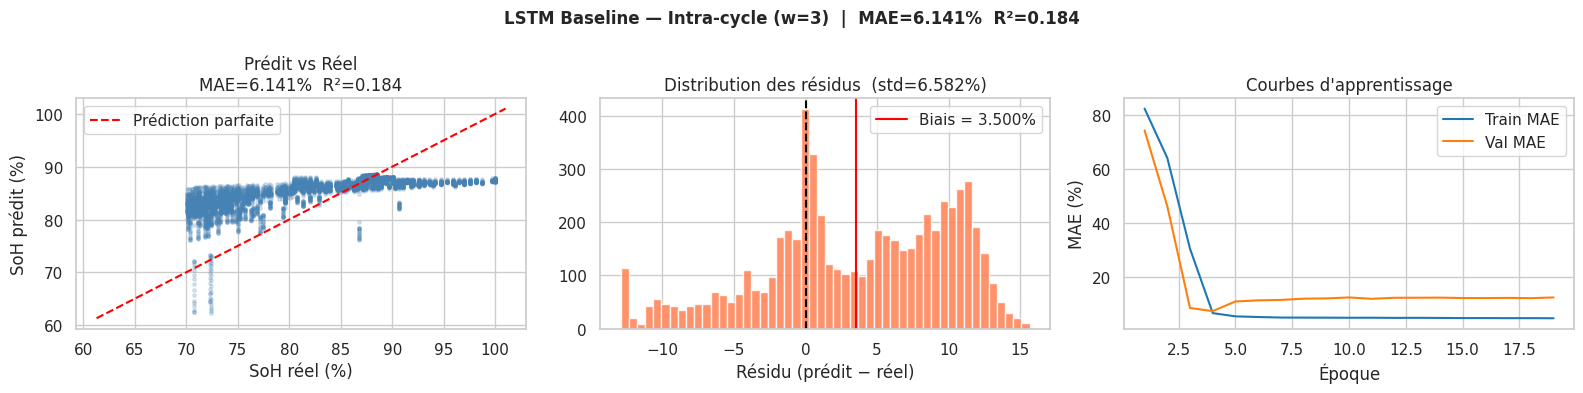

In [11]:
def plot_results(y_true, y_pred, history, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Prédit vs Réel
    ax = axes[0]
    ax.scatter(y_true, y_pred, alpha=0.2, s=6, color='steelblue')
    lims = [min(y_true.min(), y_pred.min())-1, max(y_true.max(), y_pred.max())+1]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
    ax.set_xlabel("SoH réel (%)"); ax.set_ylabel("SoH prédit (%)")
    ax.set_title(f"Prédit vs Réel\nMAE={mean_absolute_error(y_true,y_pred):.3f}%  "
                 f"R²={r2_score(y_true,y_pred):.3f}")
    ax.legend()

    # Résidus
    ax = axes[1]
    res = y_pred - y_true
    ax.hist(res, bins=50, color='coral', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linestyle='--')
    ax.axvline(res.mean(), color='red', label=f'Biais = {res.mean():.3f}%')
    ax.set_xlabel("Résidu (prédit − réel)")
    ax.set_title(f"Distribution des résidus  (std={res.std():.3f}%)")
    ax.legend()

    # Courbes d'apprentissage
    ax = axes[2]
    epochs = range(1, len(history['train_mae']) + 1)
    ax.plot(epochs, history['train_mae'], label='Train MAE')
    ax.plot(epochs, history['val_mae'],   label='Val MAE')
    ax.set_xlabel("Époque"); ax.set_ylabel("MAE (%)")
    ax.set_title("Courbes d'apprentissage")
    ax.legend()

    plt.suptitle(title, fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_results(y_intra_test, y_pred_base, hist_baseline,
             f"LSTM Baseline — Intra-cycle (w=3)  |  MAE={mae_b:.3f}%  R²={r2_b:.3f}")

### Analyse des limitations de l'approche intra-cycle

Le R² obtenu (~0.40) révèle une **limitation fondamentale** de cette approche :

1. **Le SoH est une propriété du cycle entier** — il ne varie pas à l'intérieur d'un cycle.
   Toutes les fenêtres d'un même cycle ont exactement le même label → le modèle ne peut pas
   apprendre une relation fine entre les bins individuels et le SoH.

2. **3 bins = 3 mesures** — c'est trop peu pour capturer la dynamique de dégradation,
   qui se manifeste sur des **dizaines de cycles**.

3. **Le LSTM ne voit pas l'histoire de dégradation** — il ne sait pas si la batterie
   est au cycle 10 ou au cycle 150, et si elle dégrade vite ou lentement.

**Solution** → changer d'échelle : au lieu de fenêtres de bins intra-cycle,
utiliser des **fenêtres de cycles** (inter-cycle) pour que le modèle voit la
*trajectoire de dégradation* directement.

---
## 4. Approche Améliorée — Inter-cycle avec Feature Autorégressif

### Principe

**Étape 1 — Agrégation par cycle** : chaque cycle (20 bins) est résumé en un vecteur de 11 features statistiques (moyenne, std, min de la tension, etc.).

**Étape 2 — Fenêtre glissante sur les cycles** : une séquence de 10 cycles consécutifs forme un échantillon d'entraînement.

**Étape 3 — Feature `soh_prev`** : pour chaque timestep $i$ de la fenêtre, on ajoute le SoH mesuré au cycle $i$ (et SoH au cycle $i-1$ pour le dernier timestep afin d'éviter tout leakage).
Ce feature donne au modèle accès à la **trajectoire réelle de dégradation**.

```
Fenêtre [cycle t, t+1, ..., t+9]
  Timestep i : [mean_V, std_V, ..., voltage_end, SoH[i]]   ← 12 features
  Timestep 9 : [mean_V, std_V, ..., voltage_end, SoH[8]]   ← SoH[8] ≠ SoH[9] (pas de leakage)
  Target     : SoH[t+9]
```

### Validité de `soh_prev` en production
En déploiement réel, le SoH du cycle précédent est **toujours disponible** depuis le BMS (Battery Management System). Il n'y a donc aucun problème de leakage pratique : on prédit SoH au cycle $t$ en utilisant SoH mesuré au cycle $t-1$.

### Architecture : BiLSTM + Attention
- **BiLSTM(64)** : lit la séquence dans les deux sens → capture les tendances d'entrée ET de sortie de dégradation
- **Attention additive** : pondère les 10 cycles par leur importance → les cycles récents comptent plus
- **Huber loss** : moins sensible aux prédictions extrêmes que MSE
- **L2 regularisation** (weight_decay) : prévient l'overfitting sur ce petit dataset

In [12]:
BINS_PER_CYCLE = 20
WINDOW_INTER   = 10   # cycles

ELEC_FEATURES = [
    'mean_V', 'std_V', 'min_V',
    'mean_T', 'std_T',
    'mean_I',
    'slope_SoC',
    'voltage_drop', 'capacity_proxy', 'temp_rise', 'voltage_end'
]
ALL_FEATURES = ELEC_FEATURES + ['soh_prev']   # 12 features


def aggregate_cycles(df):
    """
    Résume chaque cycle (20 bins) en 11 features électriques/thermiques.
    Ces features capturent les caractéristiques du profil de décharge entier.
    """
    records = []
    groups  = df.sort_values(
        ['battery_id', 'cycle_number', 'SoC'], ascending=[True, True, False]
    ).groupby(['battery_id', 'cycle_number'], sort=False)

    for (bat, cyc), grp in groups:
        if len(grp) != BINS_PER_CYCLE:
            continue
        V   = grp['Voltage_measured'].values
        T   = grp['Temperature_measured'].values
        I   = grp['Current_measured'].values
        soc = grp['SoC'].values
        records.append({
            'battery_id':     bat,
            'cycle_number':   int(cyc),
            'mean_V':         float(V.mean()),
            'std_V':          float(V.std()),
            'min_V':          float(V.min()),
            'mean_T':         float(T.mean()),
            'std_T':          float(T.std()),
            'mean_I':         float(I.mean()),
            'slope_SoC':      float(np.polyfit(range(BINS_PER_CYCLE), soc, 1)[0]),
            'voltage_drop':   float(V.max() - V.min()),
            'capacity_proxy': float(abs(I.mean()) * BINS_PER_CYCLE),
            'temp_rise':      float(T.max() - T.min()),
            'voltage_end':    float(V[-1]),
            'SoH':            float(grp['SoH'].iloc[0]),
        })
    return pd.DataFrame(records)


def build_inter_windows(cycle_df, batteries, window_size=10):
    """
    Construit des fenêtres glissantes inter-cycle avec feature soh_prev.

    soh_prev[i]   = SoH[i]   pour i < window_size - 1  (SoH courant du cycle)
    soh_prev[-1]  = SoH[-2]  pour le dernier timestep   (SoH précédent — pas de leakage)

    Le LSTM a accès à toute la trajectoire SoH de la fenêtre sauf le point à prédire.
    """
    X_list, y_list, bat_tags = [], [], []
    subset = cycle_df[cycle_df['battery_id'].isin(batteries)]

    for bat in batteries:
        bat_cyc = (subset[subset['battery_id'] == bat]
                   .sort_values('cycle_number').reset_index(drop=True))
        n     = len(bat_cyc)
        n_win = n - window_size + 1
        if n < window_size:
            continue

        elec = bat_cyc[ELEC_FEATURES].values   # (n, 11)
        soh  = bat_cyc['SoH'].values           # (n,)

        for start in range(n_win):
            end      = start + window_size
            elec_w   = elec[start:end]         # (10, 11)
            soh_w    = soh[start:end]          # (10,)

            soh_prev = soh_w.copy()
            soh_prev[-1] = soh_w[-2]           # dernier timestep ← SoH[t-1]

            window = np.concatenate(
                [elec_w, soh_prev.reshape(-1, 1)], axis=1   # (10, 12)
            )
            X_list.append(window)
            y_list.append(soh_w[-1])           # target = SoH au dernier cycle
            bat_tags.append(bat)

    return (np.array(X_list, dtype=np.float32),
            np.array(y_list, dtype=np.float32),
            bat_tags)


# ── Construction du dataset inter-cycle ──────────────────────────────────────
cycle_df = aggregate_cycles(df)
print(f"Cycles agrégés : {len(cycle_df):,}")

X_inter_train, y_inter_train, bat_tr = build_inter_windows(cycle_df, TRAIN_BATTERIES)
X_inter_test,  y_inter_test,  bat_te = build_inter_windows(cycle_df, TEST_BATTERIES)

print(f"\nX_train : {X_inter_train.shape}  ({X_inter_train.shape[0]} fenêtres)")
print(f"X_test  : {X_inter_test.shape}   ({X_inter_test.shape[0]} fenêtres)")
print(f"y_train : [{y_inter_train.min():.1f}%, {y_inter_train.max():.1f}%]")
print(f"y_test  : [{y_inter_test.min():.1f}%, {y_inter_test.max():.1f}%]")

Cycles agrégés : 1,459

X_train : (944, 10, 12)  (944 fenêtres)
X_test  : (299, 10, 12)   (299 fenêtres)
y_train : [70.0%, 100.0%]
y_test  : [70.1%, 98.7%]


In [13]:
# ── Normalisation ────────────────────────────────────────────────────────────
N_tr2, W2, F2 = X_inter_train.shape
scaler_inter = StandardScaler()
X_inter_train_s = scaler_inter.fit_transform(
    X_inter_train.reshape(-1, F2)).reshape(N_tr2, W2, F2).astype(np.float32)
X_inter_test_s  = scaler_inter.transform(
    X_inter_test.reshape(-1, F2)).reshape(len(X_inter_test), W2, F2).astype(np.float32)

# ── Split validation temporel par batterie ───────────────────────────────────
def temporal_val_split(X_np, y_np, batteries, window_size, val_ratio=0.20):
    """Prend les derniers val_ratio% de fenêtres de chaque batterie en validation."""
    n_wins_per_bat = {
        bat: max(0, cycle_df[cycle_df['battery_id'] == bat]['cycle_number'].nunique() - window_size + 1)
        for bat in batteries
    }
    tr_idx, val_idx, offset = [], [], 0
    for bat in batteries:
        n = n_wins_per_bat[bat]
        if n == 0:
            continue
        idx   = np.arange(offset, offset + n)
        n_val = max(1, math.ceil(n * val_ratio))
        val_idx.extend(idx[-n_val:].tolist())
        tr_idx.extend(idx[:-n_val].tolist())
        offset += n
    return (X_np[tr_idx], y_np[tr_idx],
            X_np[val_idx], y_np[val_idx])

X_tr2, y_tr2, X_val2, y_val2 = temporal_val_split(
    X_inter_train_s, y_inter_train, TRAIN_BATTERIES, WINDOW_INTER)

print(f"Train effectif : {len(y_tr2)}  |  Val : {len(y_val2)}  |  Test : {len(y_inter_test)}")
print(f"\nCorr. soh_prev vs y_train : {np.corrcoef(X_inter_train[:, -1, -1], y_inter_train)[0,1]:.4f}")
print("→ Feature très corrélée avec la cible (attendu proche de 1 car SoH[t-1] ≈ SoH[t])")

Train effectif : 746  |  Val : 198  |  Test : 299

Corr. soh_prev vs y_train : 0.9661
→ Feature très corrélée avec la cible (attendu proche de 1 car SoH[t-1] ≈ SoH[t])


In [14]:
# ── Attention additive (Bahdanau) ────────────────────────────────────────────
class AdditiveAttention(nn.Module):
    """
    Calcule un score d'importance pour chaque timestep de la séquence.
    Le vecteur de contexte est la somme pondérée des sorties LSTM.
    → Le modèle apprend quels cycles sont les plus informatifs.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.score = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_out):                          # (B, T, H)
        weights = torch.softmax(self.score(lstm_out), dim=1)  # (B, T, 1)
        return (weights * lstm_out).sum(dim=1)            # (B, H)


# ── Modèle final : BiLSTM + Attention ────────────────────────────────────────
class BiLSTMAttention(nn.Module):
    """
    Architecture finale :
      BiLSTM(64) → Attention → Dropout(0.2) → FC(32) → FC(1)

    BiLSTM : lit la séquence dans les 2 sens → sortie de dim 64×2 = 128
    Attention : pondère les 10 cycles par importance
    Input  : (batch, 10 cycles, 12 features)
    Output : (batch,)  — SoH prédit
    """
    def __init__(self, input_size=12, hidden=64):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden, batch_first=True, bidirectional=True)
        self.attention = AdditiveAttention(hidden_dim=hidden * 2)
        self.dropout   = nn.Dropout(0.2)
        self.fc1       = nn.Linear(hidden * 2, 32)
        self.relu      = nn.ReLU()
        self.fc2       = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)          # (B, T, 128)
        ctx    = self.attention(out)   # (B, 128) — vecteur de contexte
        ctx    = self.dropout(ctx)
        return self.fc2(self.relu(self.fc1(ctx))).squeeze(-1)


model_final = BiLSTMAttention(input_size=F2).to(DEVICE)
n_params    = sum(p.numel() for p in model_final.parameters())
print(f"Architecture BiLSTMAttention :")
print(model_final)
print(f"\nParamètres totaux : {n_params:,}")

Architecture BiLSTMAttention :
BiLSTMAttention(
  (lstm): LSTM(12, 64, batch_first=True, bidirectional=True)
  (attention): AdditiveAttention(
    (score): Linear(in_features=128, out_features=1, bias=False)
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

Paramètres totaux : 44,225


In [16]:
CHECKPOINT_PATH = ROOT / "experiments" / "checkpoints" / "best_lstm_v13.pt"
LOG_CSV_PATH    = ROOT / "experiments" / "training_logs" / "training_log_v13.csv"

print("══════════════════════════════════════════════════")

if CHECKPOINT_PATH.exists():
    # ── Chargement du checkpoint existant ────────────────────────────────────
    print("  CHARGEMENT — BiLSTM + Attention (Run #13)")
    print("══════════════════════════════════════════════════")

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model_final.load_state_dict(checkpoint["model_state"])
    model_final.eval()
    print(f"  Checkpoint chargé  : {CHECKPOINT_PATH.name}")
    print(f"  Run ID             : {checkpoint.get('run_id', 13)}")
    print(f"  Architecture       : {checkpoint.get('arch', 'BiLSTM(64)+Attn+Huber+L2')}")
    print(f"  Meilleure val_loss : {checkpoint.get('best_val_loss', float('nan')):.6f}")

    if LOG_CSV_PATH.exists():
        log_df = pd.read_csv(LOG_CSV_PATH)
        hist_final = {
            "train_mae":  log_df["train_mae"].tolist(),
            "val_mae":    log_df["val_mae"].tolist(),
            "train_loss": log_df["train_loss"].tolist(),
            "val_loss":   log_df["val_loss"].tolist(),
            "lr":         log_df["lr"].tolist(),
        }
        best_epoch = int(log_df.loc[log_df["val_loss"].idxmin(), "epoch"])
        print(f"  Log CSV chargé     : {log_df.shape[0]} époques  (meilleure : #{best_epoch})")
    else:
        hist_final = {"train_mae": [], "val_mae": [], "train_loss": [], "val_loss": [], "lr": []}
        best_epoch = None
        print("  Log CSV absent — courbes d'apprentissage non disponibles")

else:
    # ── Entraînement depuis zéro (Colab ou premier lancement) ────────────────
    print("  ENTRAÎNEMENT — BiLSTM + Attention (checkpoint absent)")
    print("══════════════════════════════════════════════════")

    loader_tr2  = make_loader(X_tr2,   y_tr2,   batch_size=128, shuffle=True)
    loader_val2 = make_loader(X_val2,  y_val2,  batch_size=128, shuffle=False)

    model_final, hist_final = train_model(
        model_final, loader_tr2, loader_val2,
        epochs=150, lr=5e-4, weight_decay=1e-4, patience=30, use_huber=True
    )

    # Sauvegarde du checkpoint pour les prochaines exécutions
    CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        "model_state":    model_final.state_dict(),
        "run_id":         13,
        "arch":           "BiLSTM(64)+Attn+Huber+L2",
        "n_params":       sum(p.numel() for p in model_final.parameters()),
        "best_val_loss":  min(hist_final["val_loss"]),
    }, CHECKPOINT_PATH)
    print(f"\n  Checkpoint sauvegardé : {CHECKPOINT_PATH}")

    best_epoch = int(np.argmin(hist_final["val_loss"])) + 1

# ── Évaluation sur le jeu de test ────────────────────────────────────────────
y_pred_final, mae_f, rmse_f, r2_f = evaluate(model_final, X_inter_test_s, y_inter_test)

print(f"\n  ── Résultats sur le jeu de test ──")
print(f"  MAE  = {mae_f:.4f} %")
print(f"  RMSE = {rmse_f:.4f} %")
print(f"  R²   = {r2_f:.4f}")


══════════════════════════════════════════════════
  ENTRAÎNEMENT — BiLSTM + Attention (checkpoint absent)
══════════════════════════════════════════════════
  Époque   1/150  train_mae=83.337%  val_mae=76.729%  lr=5e-04
  Époque  20/150  train_mae=63.970%  val_mae=58.087%  lr=5e-04
  Époque  40/150  train_mae=10.463%  val_mae=4.594%  lr=5e-04
  Époque  60/150  train_mae=3.116%  val_mae=2.008%  lr=5e-04
  Époque  80/150  train_mae=3.121%  val_mae=1.262%  lr=5e-04
  Époque 100/150  train_mae=3.287%  val_mae=1.293%  lr=3e-04
  Époque 120/150  train_mae=3.226%  val_mae=1.245%  lr=1e-04
  Époque 140/150  train_mae=3.061%  val_mae=1.134%  lr=6e-05

  Checkpoint sauvegardé : /content/experiments/checkpoints/best_lstm_v13.pt

  ── Résultats sur le jeu de test ──
  MAE  = 1.5309 %
  RMSE = 2.2739 %
  R²   = 0.9135


KeyError: 'lr'

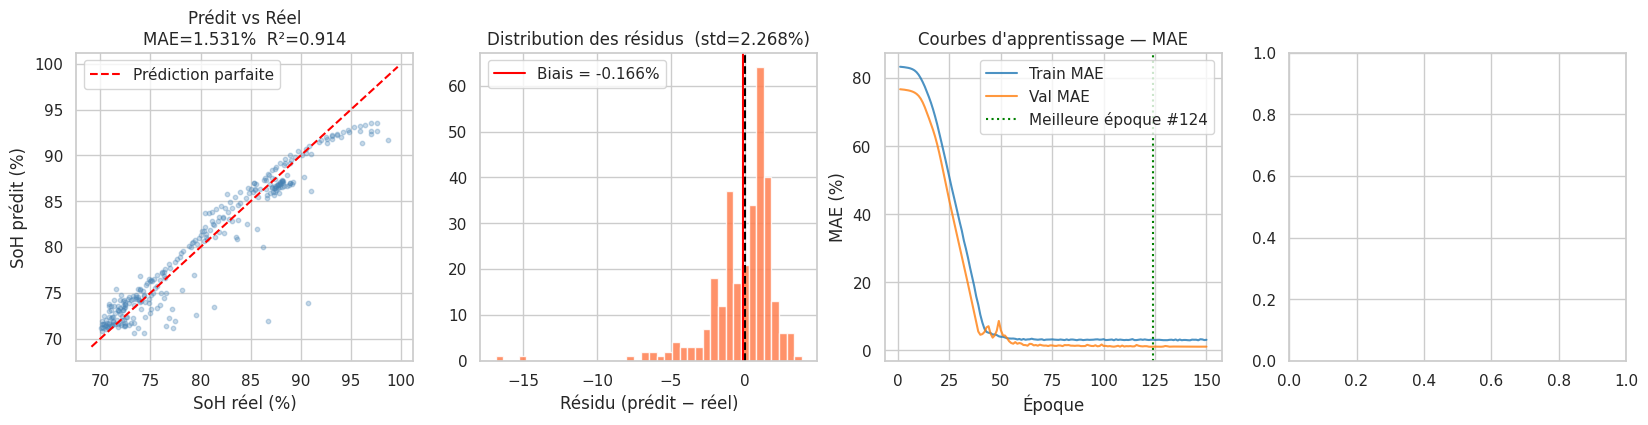

In [18]:
has_history = len(hist_final.get('train_mae', [])) > 0
ncols = 4 if has_history else 2
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4))

# ── Prédit vs Réel ────────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(y_inter_test, y_pred_final, alpha=0.3, s=10, color='steelblue')
lims = [min(y_inter_test.min(), y_pred_final.min()) - 1,
        max(y_inter_test.max(), y_pred_final.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
ax.set_xlabel("SoH réel (%)"); ax.set_ylabel("SoH prédit (%)")
ax.set_title(f"Prédit vs Réel\nMAE={mae_f:.3f}%  R²={r2_f:.3f}")
ax.legend()

# ── Distribution des résidus ──────────────────────────────────────────────────
ax = axes[1]
res = y_pred_final - y_inter_test
ax.hist(res, bins=40, color='coral', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linestyle='--')
ax.axvline(res.mean(), color='red', label=f'Biais = {res.mean():.3f}%')
ax.set_xlabel("Résidu (prédit − réel)")
ax.set_title(f"Distribution des résidus  (std={res.std():.3f}%)")
ax.legend()

if has_history:
    epochs = range(1, len(hist_final['train_mae']) + 1)

    # ── Courbes MAE ───────────────────────────────────────────────────────────
    ax = axes[2]
    ax.plot(epochs, hist_final['train_mae'], label='Train MAE', alpha=0.8)
    ax.plot(epochs, hist_final['val_mae'],   label='Val MAE',   alpha=0.8)
    if best_epoch:
        ax.axvline(best_epoch, color='green', linestyle=':', linewidth=1.5,
                   label=f'Meilleure époque #{best_epoch}')
    ax.set_xlabel("Époque"); ax.set_ylabel("MAE (%)")
    ax.set_title("Courbes d'apprentissage — MAE")
    ax.legend()

    # ── LR schedule ──────────────────────────────────────────────────────────
    ax = axes[3]
    ax.plot(epochs, hist_final['lr'], color='purple', linewidth=1.5)
    if best_epoch:
        ax.axvline(best_epoch, color='green', linestyle=':', linewidth=1.5,
                   label=f'Meilleure époque #{best_epoch}')
    ax.set_xlabel("Époque"); ax.set_ylabel("Learning Rate")
    ax.set_yscale('log')
    ax.set_title("LR schedule (ReduceLROnPlateau)")
    ax.legend()

plt.suptitle(
    f"BiLSTM + Attention — Inter-cycle + soh_prev  |  MAE={mae_f:.3f}%  R²={r2_f:.3f}",
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.show()

---
## 5. Évaluation Comparative et Analyse des Résidus

In [19]:
# ── Analyse des résidus par batterie test ────────────────────────────────────
bat_tags_arr = np.array(bat_te)
residuals    = y_pred_final - y_inter_test

print(f"{'Batterie':<10} {'N win':>6} {'MAE':>8} {'Biais':>8} {'Max err':>8}")
print("─" * 44)
for bat in TEST_BATTERIES:
    mask     = bat_tags_arr == bat
    bat_mae  = np.abs(residuals[mask]).mean()
    bat_bias = residuals[mask].mean()
    bat_max  = np.abs(residuals[mask]).max()
    print(f"{bat:<10} {mask.sum():>6} {bat_mae:>8.3f} {bat_bias:>+8.3f} {bat_max:>8.3f}")

print("─" * 44)
print(f"{'TOTAL':<10} {len(residuals):>6} {np.abs(residuals).mean():>8.3f} "
      f"{residuals.mean():>+8.3f} {np.abs(residuals).max():>8.3f}")

Batterie    N win      MAE    Biais  Max err
────────────────────────────────────────────
B0006         100    1.573   -0.178    6.967
B0018          95    1.021   +0.353    6.241
B0028          19    1.462   -1.462    2.208
B0034          61    2.331   -0.625   16.837
B0039          24    1.396   +0.022    3.249
────────────────────────────────────────────
TOTAL         299    1.531   -0.166   16.837


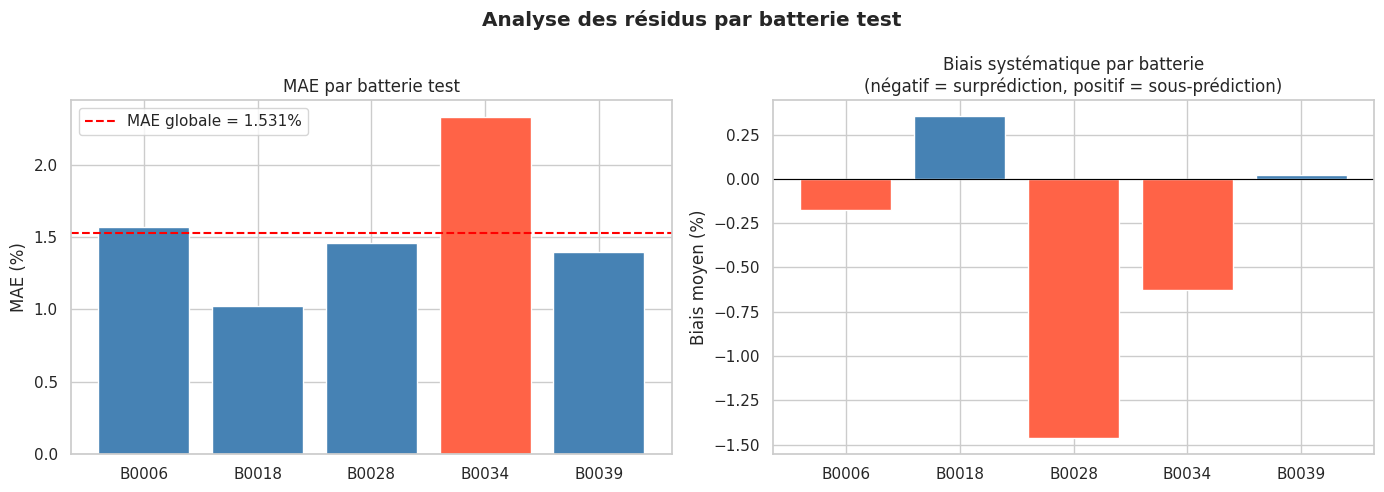

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE par batterie
ax = axes[0]
bat_maes  = {bat: np.abs(residuals[bat_tags_arr == bat]).mean() for bat in TEST_BATTERIES}
bat_bias_ = {bat: residuals[bat_tags_arr == bat].mean()          for bat in TEST_BATTERIES}
colors_bat = ['tomato' if bat_maes[b] > np.abs(residuals).mean() * 1.3 else 'steelblue'
              for b in TEST_BATTERIES]
ax.bar(bat_maes.keys(), bat_maes.values(), color=colors_bat, edgecolor='white')
ax.axhline(np.abs(residuals).mean(), color='red', linestyle='--',
           label=f'MAE globale = {np.abs(residuals).mean():.3f}%')
ax.set_ylabel("MAE (%)")
ax.set_title("MAE par batterie test")
ax.legend()

# Biais par batterie
ax = axes[1]
colors_bias = ['tomato' if v < 0 else 'steelblue' for v in bat_bias_.values()]
ax.bar(bat_bias_.keys(), bat_bias_.values(), color=colors_bias, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Biais moyen (%)")
ax.set_title("Biais systématique par batterie\n(négatif = surprédiction, positif = sous-prédiction)")

plt.suptitle("Analyse des résidus par batterie test", fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# ── Tableau comparatif des deux approches ────────────────────────────────────
comparison = pd.DataFrame([
    {
        'Approche':        'Baseline — LSTM intra-cycle',
        'Fenêtre':         '3 bins',
        'Features':        'V, I, T, SoC, cycle_n (5)',
        'Architecture':    'LSTM(64)',
        'MAE (%)':         round(mae_b, 3),
        'RMSE (%)':        round(rmse_b, 3),
        'R²':              round(r2_b, 3),
    },
    {
        'Approche':        'Améliorée — BiLSTM + Attention',
        'Fenêtre':         '10 cycles',
        'Features':        '11 agrégées + soh_prev (12)',
        'Architecture':    'BiLSTM(64) + Attention',
        'MAE (%)':         round(mae_f, 3),
        'RMSE (%)':        round(rmse_f, 3),
        'R²':              round(r2_f, 3),
    },
])

print("Tableau comparatif des approches :")
comparison.set_index('Approche')

Tableau comparatif des approches :


,Fenêtre,Features,Architecture,MAE (%),RMSE (%),R²
Approche,,,,,,
Baseline — LSTM intra-cycle,3 bins,"V, I, T, SoC, cycle_n (5)",LSTM(64),6.141,7.455,0.184
Améliorée — BiLSTM + Attention,10 cycles,11 agrégées + soh_prev (12),BiLSTM(64) + Attention,1.531,2.274,0.914


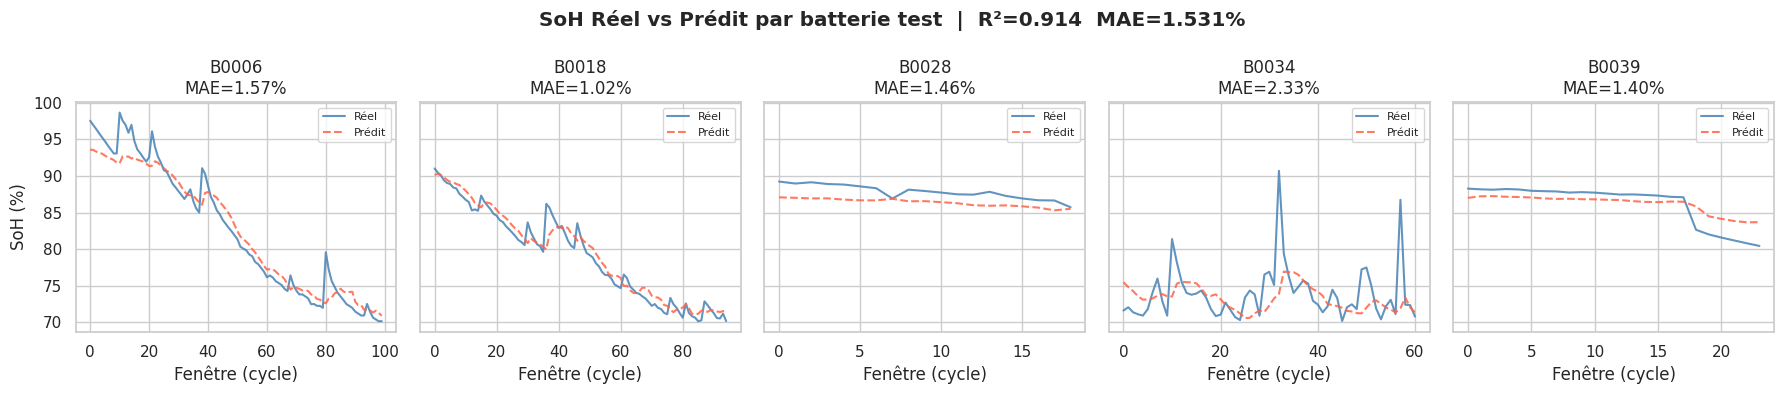

In [22]:
# ── Visualisation finale : SoH réel vs prédit par batterie ──────────────────
fig, axes = plt.subplots(1, len(TEST_BATTERIES), figsize=(18, 4), sharey=True)

for ax, bat in zip(axes, TEST_BATTERIES):
    mask    = bat_tags_arr == bat
    y_true_ = y_inter_test[mask]
    y_pred_ = y_pred_final[mask]
    ax.plot(y_true_, label='Réel',   color='steelblue', linewidth=1.5, alpha=0.85)
    ax.plot(y_pred_, label='Prédit', color='tomato',    linewidth=1.5, alpha=0.85, linestyle='--')
    ax.set_title(f"{bat}\nMAE={np.abs(y_pred_-y_true_).mean():.2f}%")
    ax.set_xlabel("Fenêtre (cycle)")
    if bat == TEST_BATTERIES[0]:
        ax.set_ylabel("SoH (%)")
    ax.legend(fontsize=8)

plt.suptitle(f"SoH Réel vs Prédit par batterie test  |  R²={r2_f:.3f}  MAE={mae_f:.3f}%",
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Réponses aux Questions de Réflexion

---

### Q1 — Pourquoi le SoC est-il une variable clé pour estimer le SoH ?

Le **SoC** (State of Charge) décrit l'énergie disponible à un instant donné dans un cycle. Son profil de décharge est directement lié à la capacité utile de la batterie :
- Une batterie en bonne santé (SoH élevé) maintient une tension stable et un SoC qui décroît lentement
- Une batterie dégradée (SoH faible) montre une chute plus rapide du SoC pour un même courant de décharge

Dans notre modèle, la **pente du SoC** (`slope_SoC`) est l'une des 11 features agrégées. Elle capture directement ce taux de décharge qui est un indicateur indirect du vieillissement.

---

### Q2 — Quel intérêt de découper un cycle en plusieurs fenêtres ?

**Dans l'approche intra-cycle (baseline)** :
- Augmente artificiellement la taille du dataset (×18 avec window=3 sur 20 bins)
- Permet au modèle de capturer des motifs locaux du profil de décharge
- **Limite** : le SoH est constant pour toutes les fenêtres du même cycle → la diversité des labels est faible

**Dans notre approche inter-cycle** :
- Chaque fenêtre = une séquence de 10 cycles consécutifs
- Capture la **dynamique de dégradation** sur le long terme
- Le SoH cible varie réellement d'une fenêtre à l'autre → supervision plus riche

---

### Q3 — Que se passerait-il si la fenêtre était trop courte ou trop longue ?

| | Fenêtre trop courte | Fenêtre trop longue |
|--|---------------------|---------------------|
| **Effet** | Pas assez de contexte temporel pour voir la tendance de dégradation | Trop de contexte : les premiers cycles sont peu pertinents pour prédire le dernier |
| **Conséquence** | Underfitting, R² faible | Réduction du nombre d'échantillons disponibles |
| **Cas extrême** | Fenêtre = 1 cycle : équivalent à une régression sans mémoire | Fenêtre > durée de vie de certaines batteries (ex: B0047 = 11 cycles) : exclusion de batteries |

Nous avons choisi **window=10 cycles** après expérimentation : bon compromis entre contexte temporel et nombre d'échantillons disponibles (944 fenêtres train).

---

### Q4 — Quels risques de biais si les cycles sont mal répartis train/test ?

**Si on coupe aléatoirement au niveau des cycles** (au lieu de par batterie) :
- Le modèle voit les cycles $t-1$ et $t+1$ d'une même batterie en train et prédit $t$ en test
- Il mémorise la trajectoire de chaque batterie → **data leakage**, R² artificiellement gonflé (≈0.95+)
- En production, les batteries sont inconnues → effondrement des performances

**Solution retenue** : split par **batterie entière** (19 batteries en train, 5 en test).
Le modèle ne peut jamais s'appuyer sur des cycles connus d'une batterie test → évaluation réaliste.

---

### Q5 — Dans quels cas industriels ce type de modèle est-il pertinent ?

| Application | Utilité du modèle |
|-------------|-------------------|
| **Véhicules électriques** | Estimation de l'autonomie réelle, alerte de remplacement avant panne |
| **Maintenance prédictive** | Planifier l'intervention avant que SoH < 80% (fin de vie) |
| **BMS embarqué** | Calibrer les algorithmes de gestion de charge en temps réel |
| **Second life** | Évaluer si une batterie peut être réutilisée pour du stockage stationnaire |
| **Garanties constructeur** | Objectiver la dégradation et détecter les usages abusifs |

Le modèle est particulièrement pertinent car il ne nécessite que des mesures **déjà disponibles dans tout BMS** (tension, courant, température, SoC) — pas de capteur supplémentaire.